<Figure size 800x600 with 0 Axes>

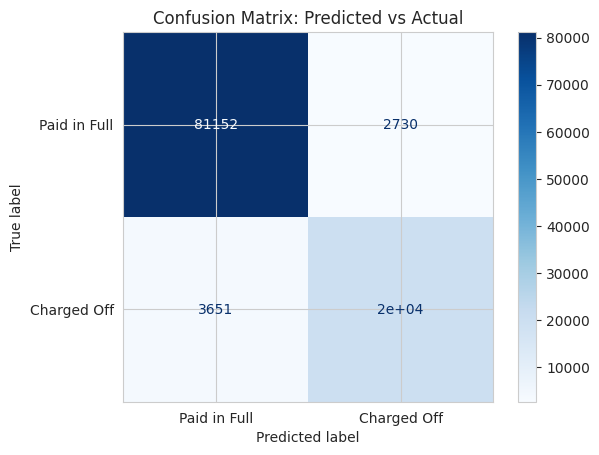

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
# Plot it
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paid in Full', 'Charged Off'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # <-- this was missing

# Generate the matrix
cm = confusion_matrix(y, y_pred_final)  # change y_pred → y_pred_final
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-wise %

labels = ['Paid in Full', 'Charged Off']

# Build annotation text: "count\n(xx%)"
annot = np.array([
    [f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})" for j in range(2)]
    for i in range(2)
])

# Plot it
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,          # color by row-normalized % so both rows are readable
    annot=annot,
    fmt='',           # using pre-formatted strings so no scientific notation
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1    # fix scale to 0–100%
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix: Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [25731, 5147]

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, color='darkorange')
plt.title('Precision-Recall Curve')
plt.show()

NameError: name 'plt' is not defined

<Figure size 800x600 with 0 Axes>

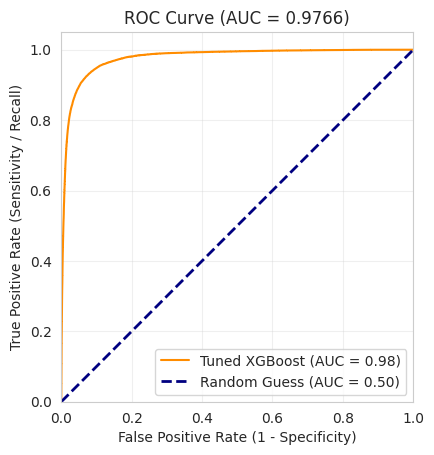

The Area Under the Curve (AUC) is: 0.9766


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# 1. Get the probability scores for the positive class (defaults)
# predict_proba returns [prob_class_0, prob_class_1]
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC-AUC score
auc_score = roc_auc_score(y_test, y_probs)

# 3. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_xgb, X_test, y_test, color='darkorange', name='Tuned XGBoost')

# Add the "Chance" line (diagonal) - what a random guesser would get
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title(f'ROC Curve (AUC = {auc_score:.4f})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"The Area Under the Curve (AUC) is: {auc_score:.4f}")

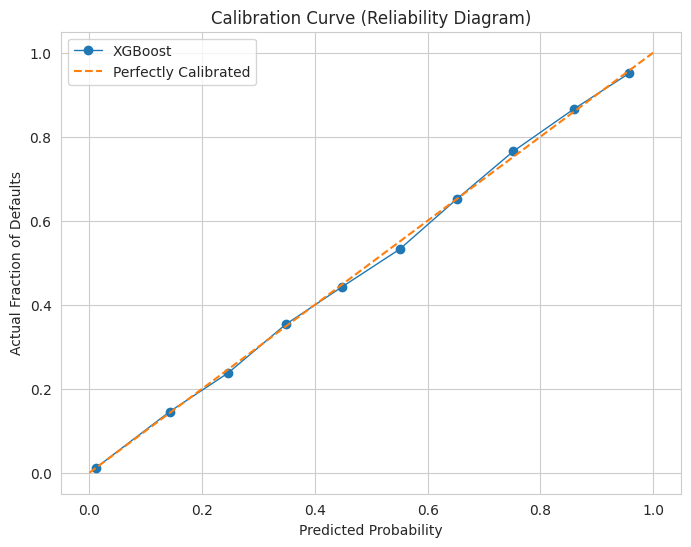

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get probabilities
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate calibration
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Fraction of Defaults')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.show()

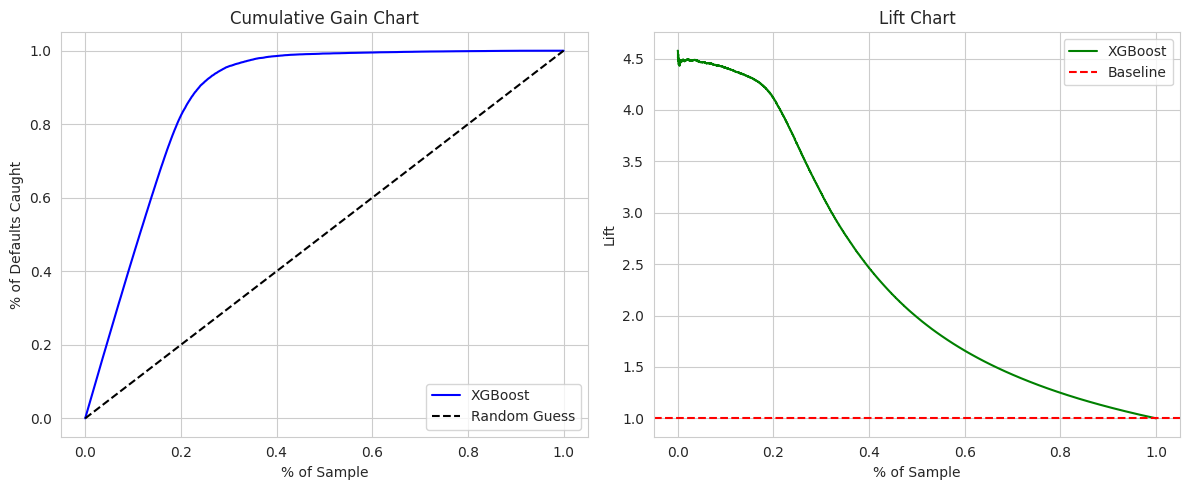

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_business_lift(y_true, y_probs):
    # Sort by probability descending
    data = pd.DataFrame({'actual': y_true, 'prob': y_probs}).sort_values('prob', ascending=False)
    data['cumulative_actual'] = data['actual'].cumsum()
    data['cumulative_all'] = np.arange(1, len(data) + 1)

    total_defaults = data['actual'].sum()

    # Gain: Percentage of total defaults caught
    data['gain'] = data['cumulative_actual'] / total_defaults
    # Lift: How much better than random
    data['lift'] = data['gain'] / (data['cumulative_all'] / len(data))

    plt.figure(figsize=(12, 5))

    # Plot Gain
    plt.subplot(1, 2, 1)
    plt.plot(np.linspace(0, 1, len(data)), data['gain'], label='XGBoost', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.title('Cumulative Gain Chart')
    plt.xlabel('% of Sample')
    plt.ylabel('% of Defaults Caught')
    plt.legend()

    # Plot Lift
    plt.subplot(1, 2, 2)
    plt.plot(np.linspace(0, 1, len(data)), data['lift'], label='XGBoost', color='green')
    plt.axhline(1, color='red', linestyle='--', label='Baseline')
    plt.title('Lift Chart')
    plt.xlabel('% of Sample')
    plt.ylabel('Lift')
    plt.legend()
    plt.tight_layout()
    plt.show()

y_probs = best_xgb.predict_proba(X_test)[:, 1]
plot_business_lift(y_test, y_probs)

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer with your trained model
explainer = shap.TreeExplainer(final_model)

# 2. Calculate SHAP values on a sample of your test data
# Using a sample (e.g., 1000 rows) makes the calculation much faster
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# 3. Create the Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SBA Credit Loan Risk Analysis - Feature Importance (SHAP)")
plt.show()

In [ ]:
auc = roc_auc_score(y_test, y_probs)
gini = 2 * auc - 1
print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.9532


In [ ]:
from sklearn.metrics import brier_score_loss
score = brier_score_loss(y_test, y_probs)
print(f"Brier Score: {score:.4f}")

Brier Score: 0.0443


In [ ]:
from sklearn.metrics import confusion_matrix

def estimate_economic_value(y_true, y_pred, cost_of_default=100000, interest_lost=10000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Savings from catching defaults - Losses from missing good loans
    value = (tp * cost_of_default) - (fp * interest_lost)
    print(f"Estimated Model Value: ${value:,.2f}")
    print(f"Total Defaults Caught: {tp}")
    print(f"Good Loans Mistakenly Denied: {fp}")

# Run for your final XGBoost predictions
estimate_economic_value(y_test, y_pred_final)

Estimated Model Value: $92,470,000.00
Total Defaults Caught: 939
Good Loans Mistakenly Denied: 143


In [ ]:
# Create a 'Risk Score' column using your trained XGBoost model
# This allows Power BI to show risk levels for every loan
df_cleaned['Risk_Probability'] = final_model.predict_proba(X)[:, 1]

# Export to a CSV that Power BI can handle easily
df_cleaned.to_csv('SBA_PowerBI_Data.csv', index=False)